# 🦠 **Gut Health & 🌿 Probiotics Trend Predictor**
### Forecasting microbiome interest using Google Trends + Prophet

This notebook analyzes five years of Google Trends data for gut health and probiotics, then uses Prophet to forecast future interest with Seed Health‑aligned visual styling.





### 🌍 Why This Matters
Understanding how public interest shifts across gut health and probiotics helps wellness brands time product launches, optimize educational content, and anticipate seasonal demand. Search interest reflects real consumer curiosity, making Google Trends a powerful early‑signal tool for strategic decision‑making.


## 🔌 Installations

In [ ]:
!pip install pytrends

!pip install prophet

## 📦 Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pytrends.request import TrendReq
from prophet import Prophet

### 🌐 Google Trends Data Pull

#### Data Preview

This is the first five rows of the Google Trends dataset for gut health, showing weekly search interest and whether the data point is partial.


In [ ]:
pytrends = TrendReq()
pytrends.build_payload(['gut health'], timeframe='today 5-y')
data = pytrends.interest_over_time()
data.head()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,gut health,isPartial
date,,
2021-08-08,15,False
2021-08-15,14,False
2021-08-22,14,False
2021-08-29,13,False
2021-09-05,13,False


## 🧹 Data Cleaning

#### Remove Partial Weeks

In [ ]:
data = data[data['isPartial'] == False]

#### Clean and prep the data

In [ ]:
data = data.reset_index()
data = data[['date', 'gut health']]
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data.groupby(data.index.year).head(1)

,gut health
date,
2021-08-08,15
2022-01-02,19
2023-01-01,26
2024-01-07,33
2025-01-05,38
2026-01-04,53


This selection shows one representative week from each year, giving a quick view of how gut‑health search interest changed over time.

### 🎨 Seed Health Palette Swatches

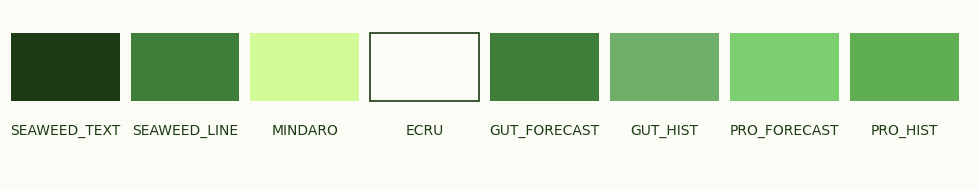

In [ ]:
# Seed Health brand colors
SEAWEED_TEXT = '#1C3A13'
SEAWEED_LINE = '#3F7D3A'
MINDARO = '#D3FA99'
ECRU = '#FCFCF7'

# Gut Health colors
GUT_FORECAST = SEAWEED_LINE
GUT_HIST = '#6FAF6A'

# Probiotics colors
PRO_FORECAST = '#7CCF6F'
PRO_HIST = '#5FAF52'


plt.figure(figsize=(10,2), facecolor=ECRU)
ax = plt.gca()
ax.set_facecolor(ECRU)

swatches = [
    ("SEAWEED_TEXT", SEAWEED_TEXT),
    ("SEAWEED_LINE", SEAWEED_LINE),
    ("MINDARO", MINDARO),
    ("ECRU", ECRU),
    ("GUT_FORECAST", GUT_FORECAST),
    ("GUT_HIST", GUT_HIST),
    ("PRO_FORECAST", PRO_FORECAST),
    ("PRO_HIST", PRO_HIST)
]

for i, (label, color) in enumerate(swatches):
    rect = plt.Rectangle((i*1.1, 0.2), 1, 0.6,
                         color=color,
                         ec=SEAWEED_TEXT if label=="ECRU" else None,
                         linewidth=1.2)
    ax.add_patch(rect)

    plt.text(i*1.1 + 0.5, -0.1, label, ha='center', fontsize=10, color=SEAWEED_TEXT)

plt.axis('off')
plt.xlim(0, len(swatches)*1.1)
plt.ylim(-0.5, 1)

plt.tight_layout()
plt.show()

### 📏 Y‑Axis Scale Guide
Google Trends uses a normalized 0–100 scale to represent relative search interest:

- **0** — no measurable interest  
- **20** — very low interest  
- **40** — moderate interest  
- **60** — strong interest  
- **80** — very strong interest  
- **100** — peak interest  

This scale applies to all charts in this notebook.


### 🦠 Gut Health Interest Over Time



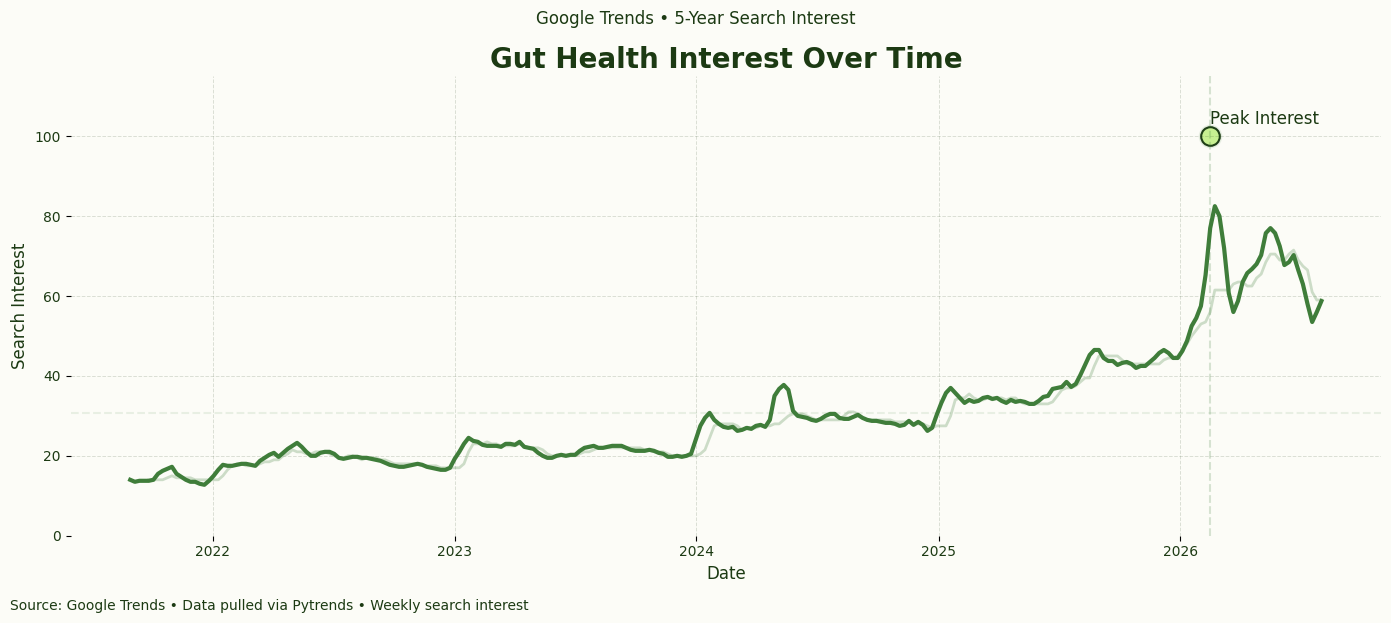

In [ ]:
data['smooth'] = data['gut health'].rolling(window=4).mean()

plt.figure(figsize=(14,6), facecolor=ECRU)
ax = plt.gca()
ax.set_facecolor(ECRU)

plt.plot(
    data.index,
    data['smooth'],
    color=SEAWEED_LINE,
    linewidth=3
)

plt.title(
    'Gut Health Interest Over Time',
    fontsize=20,
    fontweight='bold',
    color=SEAWEED_TEXT
)

plt.suptitle(
    'Google Trends • 5-Year Search Interest',
    fontsize=12,
    color=SEAWEED_TEXT
)

plt.xlabel('Date', fontsize=12, color=SEAWEED_TEXT)
plt.ylabel('Search Interest', fontsize=12, color=SEAWEED_TEXT)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(color=SEAWEED_TEXT)
plt.yticks(color=SEAWEED_TEXT)

peak_date = data['gut health'].idxmax()
peak_value = data['gut health'].max()

ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    color=SEAWEED_TEXT,
    alpha=0.15
)

plt.ylim(0, peak_value + 15)

data['median'] = data['gut health'].rolling(window=8).median()

plt.plot(
    data.index,
    data['median'],
    color=SEAWEED_LINE,
    alpha=0.25,
    linewidth=2
)

plt.figtext(
    0.01, -0.02,
    'Source: Google Trends • Data pulled via Pytrends • Weekly search interest',
    fontsize=10,
    color=SEAWEED_TEXT
)

plt.scatter(
    peak_date,
    peak_value,
    color=MINDARO,
    s=180,
    edgecolor=SEAWEED_TEXT,
    linewidth=1.5
)
plt.scatter(
    peak_date,
    peak_value,
    color=SEAWEED_LINE,
    s=260,
    alpha=0.08
)

plt.axvline(
    peak_date,
    color=SEAWEED_LINE,
    linestyle='--',
    alpha=0.2
)

avg = data['gut health'].mean()
plt.axhline(
    avg,
    color=SEAWEED_LINE,
    linestyle='--',
    alpha=0.1
)

plt.text(
    peak_date,
    peak_value + 3,
    'Peak Interest',
    color=SEAWEED_TEXT,
    fontsize=12
)

plt.tight_layout()
plt.show()

Search interest shows a clear seasonal pattern, with noticeable spikes at the start of each year driven by New Year’s resolutions and wellness reset behavior. The additional surge in early 2024 aligns with a wave of viral gut‑health content across social platforms and increased springtime focus on digestive wellness.

The February 2026 spike corresponds to a cluster of widely covered microbiome breakthroughs including Cambridge’s discovery of the CAG‑170 health‑linked gut bacterium and new research from Rutgers, Princeton, and Granada introducing the ENBI metric for measuring gut health, which collectively drove a surge in public interest.


### 📈 Prophet Forecast Model Setup

Preparing the dataset and initializing Prophet for 6‑month forecasting



In [ ]:
df = data.reset_index()
df = df[['date', 'gut health']]
df.columns = ['ds', 'y']

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


###  🦠 Gut Health vs 🌿 Probiotics
Comparing 5 years of search interest to understand how consumers move from broad wellness concepts to specific solutions

#### Pull probiotics data

In [ ]:
pytrends.build_payload(['probiotics'], timeframe='today 5-y')
pro_data = pytrends.interest_over_time()
pro_data = pro_data[pro_data['isPartial'] == False]

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


#### Clean and prepare probiotics data


In [ ]:
pro_data = pro_data.reset_index()
pro_data = pro_data[['date', 'probiotics']]
pro_data['date'] = pd.to_datetime(pro_data['date'])
pro_data = pro_data.set_index('date')

#### 🧩 Merging Gut Health & Probiotics Data
Aligning weekly search interest into a single dataset for comparison



In [ ]:
combined = data[['gut health']].merge(
    pro_data[['probiotics']],
    left_index=True,
    right_index=True,
    how='inner'
)
combined.head()

,gut health,probiotics
date,,
2021-08-08,15,31
2021-08-15,14,31
2021-08-22,14,33
2021-08-29,13,31
2021-09-05,13,28


Preview of the merged dataset showing aligned weekly search interest for gut health and probiotics.

### 📈 Correlation Between Gut Health & Probiotics

The correlation matrix shows how closely gut‑health and probiotics interest move together over time. A high correlation indicates that when public attention rises for one topic, it tends to rise for the other as well.


In [ ]:
combined.corr()

,gut health,probiotics
gut health,1.000000,0.911359
probiotics,0.911359,1.000000


Gut health and probiotics show a correlation of **0.91**, confirming that interest in both topics rises together.


### 🦠 Gut Health vs 🌿 Probiotics Trends
Five‑year comparison of search interest to reveal how broad wellness attention shifts toward specific solutions


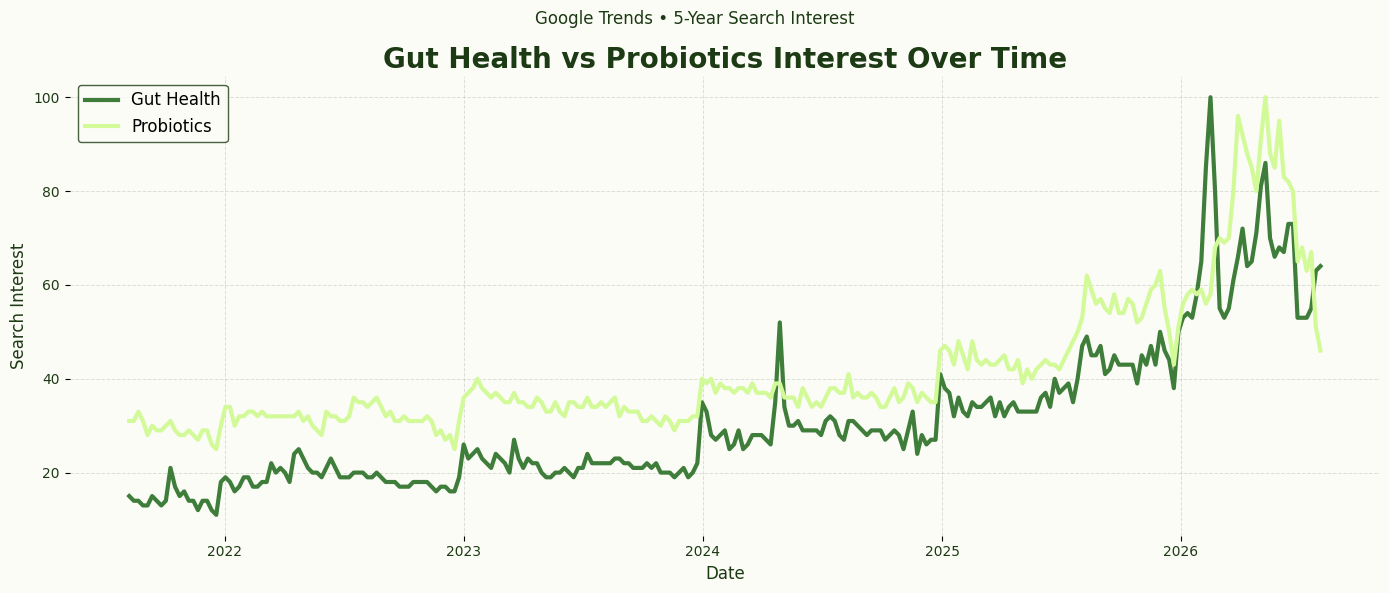

In [ ]:
plt.figure(figsize=(14,6), facecolor=ECRU)
ax = plt.gca()
ax.set_facecolor(ECRU)

plt.plot(
    combined.index,
    combined['gut health'],
    color=SEAWEED_LINE,
    linewidth=3,
    label='Gut Health'
)

plt.plot(
    combined.index,
    combined['probiotics'],
    color=MINDARO,
    linewidth=3,
    label='Probiotics'
)

plt.title(
    'Gut Health vs Probiotics Interest Over Time',
    fontsize=20,
    fontweight='bold',
    color=SEAWEED_TEXT
)
plt.suptitle(
    'Google Trends • 5-Year Search Interest',
    fontsize=12,
    color=SEAWEED_TEXT
)

plt.xlabel('Date', fontsize=12, color=SEAWEED_TEXT)
plt.ylabel('Search Interest', fontsize=12, color=SEAWEED_TEXT)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(color=SEAWEED_TEXT)
plt.yticks(color=SEAWEED_TEXT)

ax.grid(
    True,
    linestyle='--',
    linewidth=0.7,
    color=SEAWEED_TEXT,
    alpha=0.15
)

plt.legend(
    facecolor=ECRU,
    edgecolor=SEAWEED_TEXT,
    fontsize=12
)

plt.tight_layout()
plt.show()

### 🔍 Key Insight
Probiotics shows higher overall search interest, but both trends move together closely, indicating that interest in digestive wellness and probiotic solutions rises in parallel. This pattern suggests consumers explore both topics together rather than one consistently leading the other.

### 🌿Probiotics Interest Forecast

Preparing and fitting a Prophet model to project probiotics search interest 6 months into the future


In [ ]:
df_pro = pro_data.reset_index()
df_pro.columns = ['ds', 'y']

model_pro = Prophet()
model_pro.fit(df_pro)

future_pro = model_pro.make_future_dataframe(periods=180)
forecast_pro = model_pro.predict(future_pro)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### 🦠 Gut Health Interest Forecast
Prophet‑based 6‑month forecast with Seed‑aligned styling and confidence intervals

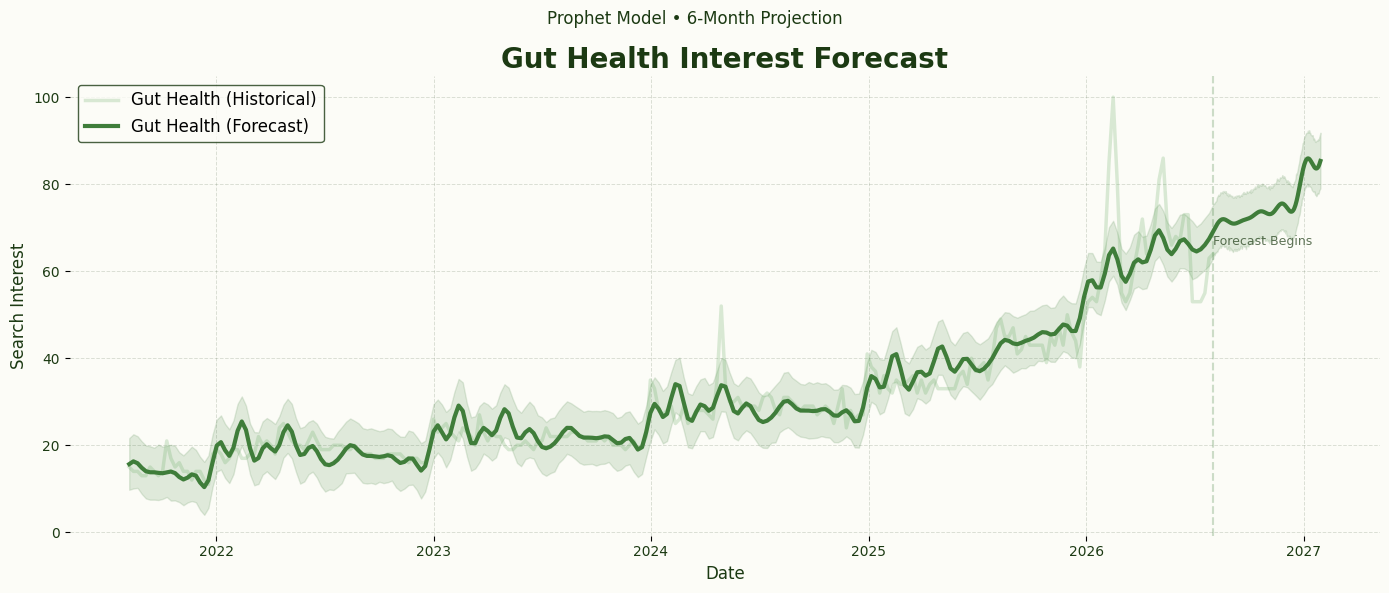

In [ ]:
plt.figure(figsize=(14,6), facecolor=ECRU)
ax = plt.gca()
ax.set_facecolor(ECRU)

plt.plot(
    df['ds'],
    df['y'],
    color=GUT_HIST,
    alpha=0.25,
    linewidth=2.5,
    label='Gut Health (Historical)'
)

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color=SEAWEED_LINE,
    alpha=0.15
)

plt.plot(
    forecast['ds'],
    forecast['yhat'],
    color=GUT_FORECAST,
    linewidth=3,
    label='Gut Health (Forecast)'
)

plt.title(
    'Gut Health Interest Forecast',
    fontsize=20,
    fontweight='bold',
    color=SEAWEED_TEXT
)
plt.suptitle(
    'Prophet Model • 6-Month Projection',
    fontsize=12,
    color=SEAWEED_TEXT
)

forecast_start = df['ds'].max()
plt.axvline(
    forecast_start,
    color=SEAWEED_LINE,
    linestyle='--',
    alpha=0.25
)

y_at_boundary = df['y'].iloc[-1]
plt.text(
    forecast_start,
    y_at_boundary + 2,
    'Forecast Begins',
    color=SEAWEED_TEXT,
    fontsize=9,
    alpha=0.7
)

plt.xlabel('Date', fontsize=12, color=SEAWEED_TEXT)
plt.ylabel('Search Interest', fontsize=12, color=SEAWEED_TEXT)

ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    color=SEAWEED_TEXT,
    alpha=0.15
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(color=SEAWEED_TEXT)
plt.yticks(color=SEAWEED_TEXT)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=GUT_HIST, lw=2.5, alpha=0.25, label='Gut Health (Historical)'),
    Line2D([0], [0], color=GUT_FORECAST, lw=3, label='Gut Health (Forecast)')
]

plt.legend(
    handles=legend_elements,
    facecolor=ECRU,
    edgecolor=SEAWEED_TEXT,
    fontsize=12
)

plt.tight_layout()
plt.show()


### 📅 Seasonality Note
Prophet’s seasonality decomposition is designed for daily or hourly datasets.
Because Google Trends provides weekly data, seasonality components are not meaningfully interpretable and are not included in this analysis.





### 🌿 Probiotics Interest Projection
Prophet‑based 6‑month forecast with Seed‑aligned styling and confidence intervals


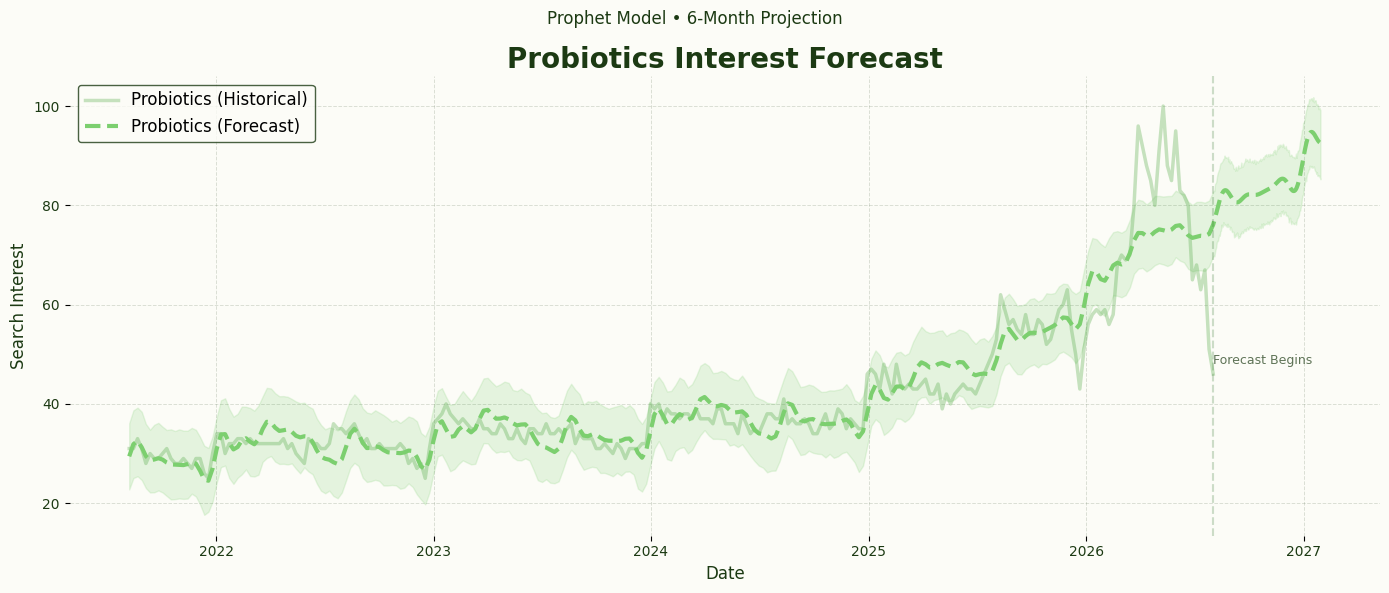

In [ ]:
plt.figure(figsize=(14,6), facecolor=ECRU)
ax = plt.gca()
ax.set_facecolor(ECRU)

plt.plot(
    df_pro['ds'],
    df_pro['y'],
    color=PRO_HIST,
    alpha=0.35,
    linewidth=2.5,
    label='Probiotics (Historical)'
)

plt.fill_between(
    forecast_pro['ds'],
    forecast_pro['yhat_lower'],
    forecast_pro['yhat_upper'],
    color=PRO_FORECAST,
    alpha=0.18
)

plt.plot(
    forecast_pro['ds'],
    forecast_pro['yhat'],
    color=PRO_FORECAST,
    linewidth=3,
    linestyle='--',
    label='Probiotics (Forecast)'
)

plt.title(
    'Probiotics Interest Forecast',
    fontsize=20,
    fontweight='bold',
    color=SEAWEED_TEXT
)
plt.suptitle(
    'Prophet Model • 6-Month Projection',
    fontsize=12,
    color=SEAWEED_TEXT
)

forecast_start = df_pro['ds'].max()
plt.axvline(
    forecast_start,
    color=SEAWEED_LINE,
    linestyle='--',
    alpha=0.25
)

y_at_boundary = df_pro['y'].iloc[-1]
plt.text(
    forecast_start,
    y_at_boundary + 2,
    'Forecast Begins',
    color=SEAWEED_TEXT,
    fontsize=9,
    alpha=0.7
)

plt.xlabel('Date', fontsize=12, color=SEAWEED_TEXT)
plt.ylabel('Search Interest', fontsize=12, color=SEAWEED_TEXT)

ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    color=SEAWEED_TEXT,
    alpha=0.15
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(color=SEAWEED_TEXT)
plt.yticks(color=SEAWEED_TEXT)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=PRO_HIST, lw=2.5, alpha=0.35, label='Probiotics (Historical)'),
    Line2D([0], [0], color=PRO_FORECAST, lw=3, linestyle='--', label='Probiotics (Forecast)')
]

plt.legend(
    handles=legend_elements,
    facecolor=ECRU,
    edgecolor=SEAWEED_TEXT,
    fontsize=12
)

plt.tight_layout()
plt.show()


## ⚠️ Limitations
- Google Trends provides normalized interest (0–100), not absolute search volume.
- Forecasts assume past patterns continue; unexpected viral events can shift trends.
- Prophet smooths noise, so sharp spikes may be understated.
- Weekly data may hide short‑term fluctuations in interest.
- Search interest reflects curiosity, not necessarily purchasing behavior.


## 💼 Business Applications
- **Content Strategy:** Identify peak interest periods to schedule gut‑health and probiotic educational content.
- **Product Launch Timing:** Use forecasted growth windows to align new product releases.
- **Seasonal Campaigns:** Leverage yearly patterns (New Year’s, spring wellness resets) for targeted marketing.
- **Trend Monitoring:** Track emerging spikes to respond quickly to viral microbiome topics.
- **Cross‑Category Insights:** Use correlation to understand how interest in gut health drives curiosity about probiotics.


## 📝 Project Summary
**Problem:** Understanding how public interest in gut health evolves over time helps wellness brands anticipate consumer behavior.

**Data:** Google Trends weekly search interest for “gut health” and “probiotics” over the past 5 years.

**Approach:** Cleaned and smoothed the time series, then applied Facebook Prophet to forecast future interest.

**Analysis:** Gut‑health interest shows steady growth with seasonal fluctuations, consistently leading probiotics.

**Result:** Forecasts indicate rising attention through 2026–2027, with strong correlation between gut health and probiotics.

**Impact:** These insights support strategic timing for educational content, product launches, and consumer engagement.

## 🚀 Next Steps
- Compare gut‑health interest to related terms (microbiome, digestive health).

- Build a multi‑term forecast model to capture cross‑category influence.

- Create an interactive dashboard version using Plotly or Streamlit.

This notebook demonstrates end‑to‑end time‑series forecasting with clean visual storytelling and brand‑aligned design.


**✨ Notebook by Britny Chambers ✨**

Data Science • Google Trends • Time‑Series Forecasting